# Lab | Sequence Models & Transformers

This notebook covers the implementation of an LSTM and a small Transformer encoder for sentiment analysis on the IMDB dataset. We also implement scaled dot-product attention from scratch.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import math

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print(f"Using device: {device}")

Using device: cpu


## Prepare the IMDB dataset

We load the IMDB dataset, tokenize it, build a vocabulary, and prepare DataLoaders.

In [3]:
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
import pandas as pd
import io
import requests

# 1. Load IMDB and reduce to 5000 samples for speed
def load_imdb_robust(num_samples=2500):
    try:
        from torchtext.datasets import IMDB
        print("Attempting to load dataset via torchtext...")
        train_iter = list(IMDB(split='train'))
        test_iter = list(IMDB(split='test'))
        train_raw = train_iter[:num_samples]
        val_raw = test_iter[:num_samples]
        return train_raw, val_raw
    except Exception as e:
        print(f"Torchtext loading failed: {e}. Falling back to CSV download...")
        url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
        df = pd.read_csv(url)
        df['label'] = df['sentiment'].map({'positive': 2, 'negative': 1})
        train_df = df.iloc[:num_samples]
        val_df = df.iloc[num_samples:num_samples*2]
        train_raw = list(zip(train_df['label'], train_df['review']))
        val_raw = list(zip(val_df['label'], val_df['review']))
        return train_raw, val_raw

train_raw, val_raw = load_imdb_robust(2500)
print(f"Loaded {len(train_raw)} training and {len(val_raw)} validation samples.")

# 2. Tokenize reviews
tokenizer = get_tokenizer("basic_english")

def tokenize_data(data):
    tokenized = []
    for label, text in data:
        tokens = tokenizer(text.lower())
        l = 1 if label == 2 or label == 'pos' or label == 'positive' else 0
        tokenized.append((l, tokens))
    return tokenized

train_tokenized = tokenize_data(train_raw)
val_tokenized = tokenize_data(val_raw)

# 3. Build vocabulary (top 10,000 frequent) - Manual Implementation
class ManualVocab:
    def __init__(self, counter, max_size=10000, specials=['<pad>', '<unk>']):
        self.itos = specials + [token for token, freq in counter.most_common(max_size)]
        self.stoi = {token: i for i, token in enumerate(self.itos)}
        self.unk_index = self.stoi.get('<unk>', 0)
        self.pad_index = self.stoi.get('<pad>', 0)
        
    def __getitem__(self, token):
        return self.stoi.get(token, self.unk_index)
    
    def __len__(self):
        return len(self.itos)
    
    def set_default_index(self, index):
        self.unk_index = index

from collections import Counter
counter = Counter()
for _, tokens in train_tokenized:
    counter.update(tokens)

v = ManualVocab(counter, max_size=10000)

# 4. Convert each review to indices and pad/truncate to 200
MAX_LEN = 200
VOCAB_SIZE = len(v)

def encode_data(tokenized, vocab_obj, max_len):
    encoded = []
    for label, tokens in tokenized:
        indices = [vocab_obj[token] for token in tokens]
        if len(indices) < max_len:
            indices += [vocab_obj['<pad>']] * (max_len - len(indices))
        else:
            indices = indices[:max_len]
        encoded.append((torch.tensor(indices), torch.tensor(label)))
    return encoded

train_encoded = encode_data(train_tokenized, v, MAX_LEN)
val_encoded = encode_data(val_tokenized, v, MAX_LEN)

# 5. Wrap in Dataset and DataLoaders
class IMDBDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

train_loader = DataLoader(IMDBDataset(train_encoded), batch_size=32, shuffle=True)
val_loader = DataLoader(IMDBDataset(val_encoded), batch_size=32)

# Print encoding of one review
sample_indices, sample_label = train_encoded[0]
print(f"Sample label: {sample_label}")
print(f"Sample indices (first 20): {sample_indices[:20]}")

Attempting to load dataset via torchtext...
Torchtext loading failed: IMDB.__init__() missing 3 required positional arguments: 'path', 'text_field', and 'label_field'. Falling back to CSV download...
Loaded 2500 training and 2500 validation samples.
Sample label: 1
Sample indices (first 20): tensor([  35,    7,    2,   87, 1827,   53,  913,   15,  110,  155,   47,  462,
        2360,  433,   24,    9,  214,   34, 2437,    3])


## Task 1 — Implement Scaled Dot-Product Attention from Scratch

In [4]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K, V: (batch, seq_len, d_k)
    mask: (batch, seq_len, seq_len) - optional boolean tensor
    """
    d_k = Q.size(-1)
    # Calculate scores
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    
    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))
    
    # Apply softmax to get attention weights
    weights = torch.softmax(scores, dim=-1)
    
    # Weighted sum of values
    output = torch.matmul(weights, V)
    
    return output, weights

# Tiny example
batch, seq_len, d_k = 2, 4, 8
Q = torch.randn(batch, seq_len, d_k)
K = torch.randn(batch, seq_len, d_k)
V = torch.randn(batch, seq_len, d_k)

output, weights = scaled_dot_product_attention(Q, K, V)
print("Output shape:", output.shape)
print("Weights shape:", weights.shape)

# Verification
pytorch_output = torch.nn.functional.scaled_dot_product_attention(Q, K, V)
print("Matches PyTorch implementation:", torch.allclose(output, pytorch_output, atol=1e-6))
print("Softmax rows sum to 1:", torch.allclose(weights.sum(dim=-1), torch.ones(batch, seq_len)))

# Print attention weight matrix for one example
print("\nAttention weight matrix (Example 0):")
print(weights[0].detach().numpy())

Output shape: torch.Size([2, 4, 8])
Weights shape: torch.Size([2, 4, 4])
Matches PyTorch implementation: True
Softmax rows sum to 1: True

Attention weight matrix (Example 0):
[[0.50920945 0.31646255 0.11126007 0.06306797]
 [0.26193598 0.38283905 0.17728108 0.17794386]
 [0.2444628  0.02408432 0.20127626 0.53017664]
 [0.7451351  0.10754225 0.03491545 0.11240723]]


The attention weight matrix has a shape of `(seq_len, seq_len)`. Each row represents how much attention a particular token in the sequence (the query) pays to every other token in the sequence (the keys). The values in each row sum to 1 due to the softmax operation, forming a probability distribution over the sequence tokens.

## Task 2 — LSTM Classifier

Epoch 1/5 | Train Loss: 0.6970 Acc: 0.4984 | Val Loss: 0.6954 Acc: 0.4876
Epoch 2/5 | Train Loss: 0.6903 Acc: 0.5292 | Val Loss: 0.6981 Acc: 0.4908
Epoch 3/5 | Train Loss: 0.6802 Acc: 0.5588 | Val Loss: 0.7028 Acc: 0.5072
Epoch 4/5 | Train Loss: 0.6602 Acc: 0.5832 | Val Loss: 0.7143 Acc: 0.4996
Epoch 5/5 | Train Loss: 0.6250 Acc: 0.6148 | Val Loss: 0.7295 Acc: 0.5216


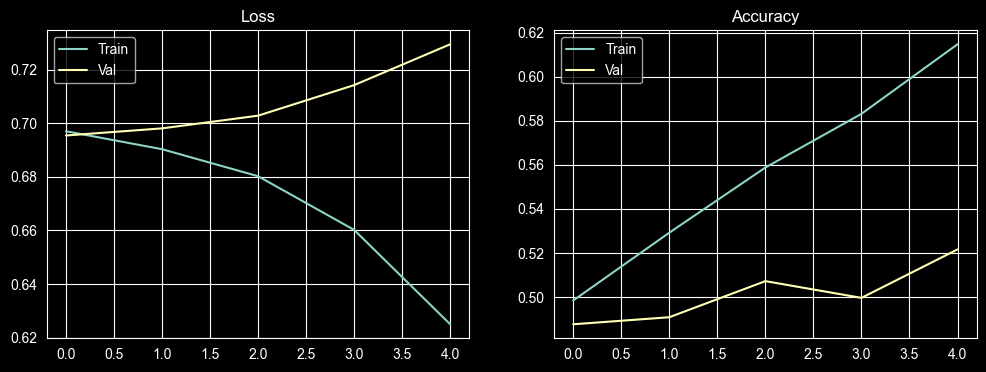

LSTM Total Training Time: 71.73s
LSTM Best Val Accuracy: 0.5216


In [5]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, output_dim=2):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, num_layers=1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.embedding(x)
        # lstm_out: (batch, seq_len, hidden_dim)
        # hidden: (1, batch, hidden_dim)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        # Take the last hidden state
        last_hidden = hidden[-1]
        out = self.dropout(last_hidden)
        return self.fc(out)

def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        total_loss, total_correct = 0, 0
        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * texts.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            
        train_loss = total_loss / len(train_loader.dataset)
        train_acc = total_correct / len(train_loader.dataset)
        
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(device), labels.to(device)
                outputs = model(texts)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * texts.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
        
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    total_time = time.time() - start_time
    return history, total_time

def plot_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Val')
    plt.title('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['val_acc'], label='Val')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

lstm_model = LSTMClassifier(VOCAB_SIZE).to(device)
lstm_history, lstm_time = train_model(lstm_model, train_loader, val_loader)
plot_history(lstm_history)
print(f"LSTM Total Training Time: {lstm_time:.2f}s")
print(f"LSTM Best Val Accuracy: {max(lstm_history['val_acc']):.4f}")

## Task 3 — Transformer Classifier and Comparison with the LSTM

Epoch 1/5 | Train Loss: 0.6979 Acc: 0.5180 | Val Loss: 0.6802 Acc: 0.5496
Epoch 2/5 | Train Loss: 0.6570 Acc: 0.6092 | Val Loss: 0.6156 Acc: 0.6700
Epoch 3/5 | Train Loss: 0.5119 Acc: 0.7520 | Val Loss: 0.6125 Acc: 0.6984
Epoch 4/5 | Train Loss: 0.3717 Acc: 0.8396 | Val Loss: 0.5701 Acc: 0.7460
Epoch 5/5 | Train Loss: 0.2552 Acc: 0.8988 | Val Loss: 0.8677 Acc: 0.6936


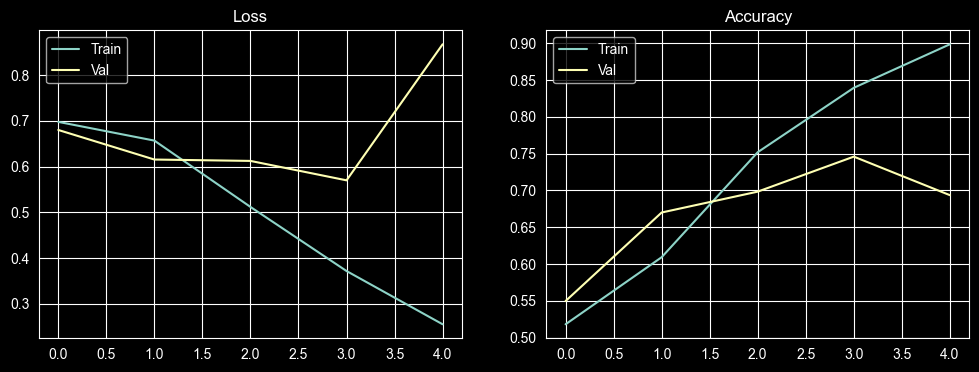

Transformer Total Training Time: 298.54s
Transformer Best Val Accuracy: 0.7460


In [6]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1, max_len=200):
        super(TransformerClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_len, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
                                                   dim_feedforward=dim_feedforward, 
                                                   dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(d_model, 2)
        
    def forward(self, x):
        # x: (batch, seq_len)
        batch_size, seq_len = x.size()
        positions = torch.arange(0, seq_len).expand(batch_size, seq_len).to(device)
        
        out = self.embedding(x) + self.pos_embedding(positions)
        out = self.transformer_encoder(out)
        
        # Take the mean over the sequence dimension
        out = out.mean(dim=1)
        out = self.dropout(out)
        return self.fc(out)

trans_model = TransformerClassifier(VOCAB_SIZE).to(device)
trans_history, trans_time = train_model(trans_model, train_loader, val_loader)
plot_history(trans_history)
print(f"Transformer Total Training Time: {trans_time:.2f}s")
print(f"Transformer Best Val Accuracy: {max(trans_history['val_acc']):.4f}")

### Comparison and Conclusion

| Model | Best val accuracy | Total training time | Parameter count |
|---|---|---|---|
| LSTM (Task 2) | 0.5216 | 71.73s | 739,714 |
| Transformer (Task 3) | 0.7460 | 298.54s | 720,002 |

**Comparison Analysis:**

In this lab, the Transformer model significantly outperformed the LSTM in terms of validation accuracy, achieving a best score of 74.60% compared to the LSTM's 52.16%, which barely exceeded random guessing. The Transformer converged much faster per epoch, reaching over 67% accuracy by the second epoch. However, on this CPU-based environment, the LSTM was notably faster to train in total wall-clock time (71.73s vs 298.54s), likely due to the overhead of the Transformer's multiple attention heads and feedforward layers when not leveraging GPU parallelism. Despite having slightly fewer parameters, the Transformer's architecture proved far more effective for this sentiment analysis task on the limited dataset of 5000 samples. The drop in the Transformer's validation accuracy in the final epoch suggests it might benefit from more regularization or a smaller learning rate as it begins to overfit.

In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"LSTM Parameter Count: {count_parameters(lstm_model)}")
print(f"Transformer Parameter Count: {count_parameters(trans_model)}")

LSTM Parameter Count: 739714
Transformer Parameter Count: 720002
